The metric I will be looking at to determine the best neighborhood is crime reports. First let's load the file:

In [3]:
import pandas as pd
import os

crime = pd.read_csv("CrimeActivity.csv", sep = ',', low_memory=False)

Unfortunately, some of the names of the neighborhoods weren't standardized across multiple data sets. Let's fix that by linking the names that caused issues to the same name, allowing the names to be corrected. We will also count every crime report that occured in each neighborhood:

In [4]:
crime['Neighborhood'] = crime['Neighborhood'].replace({'Lincoln-Lemington-Belmar': 'Lincoln–Lemington–Belmar', 'Arlington': 'Arlington - Arlington Heights (Combined)',
    'Arlington Heights': 'Arlington - Arlington Heights (Combined)'})
crime_counts = crime['Neighborhood'].value_counts().reset_index()
crime_counts.columns = ['Neighborhood', 'CrimeReports']

print(crime_counts)

                 Neighborhood  CrimeReports
0   Central Business District          7218
1            South Side Flats          4631
2                     Carrick          2242
3                   Shadyside          1993
4              East Allegheny          1917
..                        ...           ...
84             Swisshelm Park            66
85              New Homestead            54
86                  Chartiers            38
87                  Ridgemont            33
88                Saint Clair            25

[89 rows x 2 columns]


These are interesting results, but they don't tell the full story. Some neighborhoods have a higher population, naturally resulting in higher crime reports than those with lower populations. To fix this we can use our population dataset to standardize the crime reports.

In [7]:
population = pd.read_csv("Population.csv")

merged_df = crime_counts.merge(population[['Neighborhood', '2020_Total_Population']],
                               on='Neighborhood', how='left')

#print(merged_df)

This calculation is used to determine the amount of crime reports per 1000 residents, resulting in a more accurate representation of crime.

In [8]:
merged_df['CrimePer1000'] = merged_df['CrimeReports'] / merged_df['2020_Total_Population'] * 1000
#print(merged_df)

Now let us create a graph to represent this data.

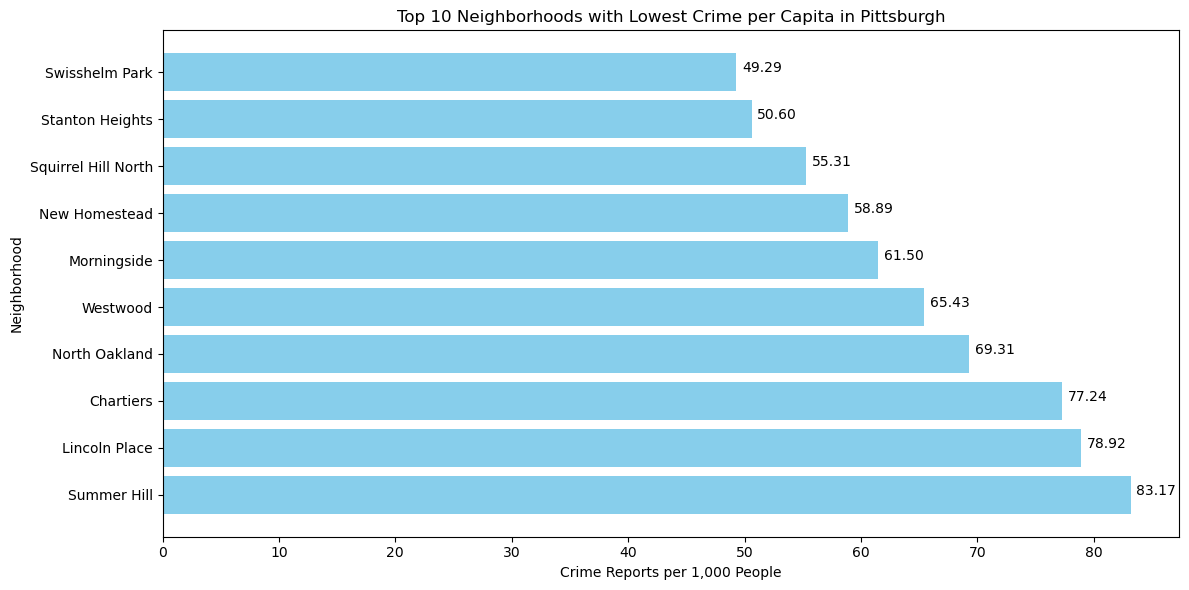

In [9]:
import matplotlib.pyplot as plt

lowest_10 = merged_df.sort_values('CrimePer1000').head(10)

plt.figure(figsize=(12,6))
plt.barh(
    lowest_10['Neighborhood'], 
    lowest_10['CrimePer1000'], 
    color='skyblue'
)

plt.xlabel('Crime Reports per 1,000 People')
plt.ylabel('Neighborhood')
plt.title('Top 10 Neighborhoods with Lowest Crime per Capita in Pittsburgh')
plt.gca().invert_yaxis()  # Invert y-axis to have the lowest on top

for index, value in enumerate(lowest_10['CrimePer1000']):
    plt.text(value + 0.5, index, f'{value:.2f}')

plt.tight_layout()
plt.show()
#print(lowest_10[['Neighborhood', 'CrimeReports', '2020_Total_Population', 'CrimePer1000']])

Now that we have our neighborhoods ranked by crime reports, we can derive a score for each to be used in our final calculation for the winner. This can be done using a percentile score, with the neighborhood with the lowest crime per 1000 having the highest score and the neighborhood with the highest crime per 1000 having the lower score.

In [10]:
min_crime = merged_df['CrimePer1000'].min()
max_crime = merged_df['CrimePer1000'].max()

merged_df['CrimeScore Percentile'] = 1 - merged_df['CrimePer1000'].rank(method='average', pct=True)
pd.set_option('display.max_rows', None)
pd.set_option('display.width', 200)
print(merged_df[['Neighborhood', 'CrimePer1000', 'CrimeScore Percentile']].sort_values('CrimeScore Percentile', ascending=False))

                                Neighborhood  CrimePer1000  CrimeScore Percentile
84                            Swisshelm Park     49.290515               0.988764
67                           Stanton Heights     50.598600               0.977528
33                       Squirrel Hill North     55.307686               0.966292
85                             New Homestead     58.887677               0.955056
70                               Morningside     61.500615               0.943820
68                                  Westwood     65.426170               0.932584
29                             North Oakland     69.310635               0.921348
86                                 Chartiers     77.235772               0.910112
62                             Lincoln Place     78.922345               0.898876
81                               Summer Hill     83.166333               0.887640
56                                Banksville     83.595832               0.876404
87              

## Conclusion

Of course, it is difficult to decide on an absolute "best" neighborhood as everyone has their own criteria and metrics for what the "best" truly is. But, based purely on these results, It seems like Swisshelm Park is the best neighborhood in terms of crime. This is a very valuable metric to consider, especially if someone is looking to move somewhere, but using just these crime reports is a bit misguided. This analysis does not consider the severity of the crime reports, only the number of reports. If someone were moving to Pittsburgh and wanted to use crime as a very important metric to consider, they might want to look for the area with the least severe crime reports rather than total crime reports. Personally, as someone who has only been here for a couple months and has not gone far from campus, my favorite neighborhood is North Oakland as that is where I have spent the majority of my time here. Luckily, this metric does not totally disagree with me as North Oakland is in the top 10 neighborhoods with the lowest crime per capita. Overall though, determining a "best" neighborhood is very complicated and is entirely up to the individual to decide what they believe would be the best.